In [ ]:
!pip install -q python-igraph scikit-learn ripser persim openTSNE GraphRicciCurvature

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.3/841.3 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 10.8 MB/s eta 0:00:00


In [ ]:
import torch
from torch.utils.data import Subset
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

# Define the transformation pipeline:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float()),  # Binarize the image
    transforms.Lambda(lambda x: x.view(-1))           # Flatten into a 784-dim vector
])

# Load the training set (set download=True if running for the first time)
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Get indices for images where the label is 1
indices = (mnist_train.targets == 1).nonzero().squeeze()

# Create a subset containing only the '1's
mnist_train_ones = Subset(mnist_train, indices)

print(f"Total number of '1' images in the training set: {len(mnist_train_ones)}")

# Stack all 784-dim vectors from the filtered dataset
all_vectors = torch.stack([img for img, _ in mnist_train_ones])
unique_vectors = torch.unique(all_vectors, dim=0)

print(f"Total images in mnist_train_ones: {all_vectors.shape[0]}")
print(f"Unique images: {unique_vectors.shape[0]}")

if all_vectors.shape[0] == unique_vectors.shape[0]:
    print("All 784-dimensional vectors are unique.")
else:
    print("There are duplicates in the 784-dimensional vectors.")

vectors_np = unique_vectors.numpy()

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.14MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 167kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.23MB/s]


Total number of '1' images in the training set: 6742
Total images in mnist_train_ones: 6742
Unique images: 6726
There are duplicates in the 784-dimensional vectors.


In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import igraph as ig

def build_weighted_filtered_knn_graph(X, k, max_distance=6.0):
    """
    Builds an undirected k-NN graph on `unique_vectors` but only keeps edges
    whose Euclidean length ≤ max_distance.  Each edge gets a 'weight' attribute
    equal to its Euclidean distance.

    Parameters
    ----------
    unique_vectors : array-like, shape (n, d)
        Your dataset (can be a numpy array or a torch tensor with .numpy()).
    k : int
        The number of nearest neighbours to consider per point.
    max_distance : float
        The distance threshold for pruning edges.

    Returns
    -------
    g : igraph.Graph
        An undirected graph on n vertices with only the filtered edges, and
        g.es['weight'] giving each edge’s Euclidean length.
    """
    n = X.shape[0]
    print(f"Building weighted filtered k-NN graph for {n} nodes with edge dist ≤ {max_distance}...")

    # find k+1 neighbors (including self)
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
    distances, indices = nbrs.kneighbors(X)

    edge_list = []
    weight_list = []
    for i, (neighbors, dists) in enumerate(zip(indices, distances)):
        # skip the first neighbor (itself)
        for j, dist in zip(neighbors[1:], dists[1:]):
            # only add each edge once (i<j) and only if within threshold
            if dist <= max_distance and i < j:
                edge_list.append((i, j))
                weight_list.append(dist)

    # build igraph and assign weights
    g = ig.Graph(n=n, edges=edge_list, directed=False)
    g.es['weight'] = weight_list

    print(f"Graph built: {n} vertices, {g.ecount()} edges.")
    return g

g_weighted = build_weighted_filtered_knn_graph(vectors_np, k=5, max_distance=6)


Building weighted filtered k-NN graph for 6726 nodes with edge dist ≤ 6...
Graph built: 6726 vertices, 15068 edges.


In [ ]:
# find all connected components
components = g_weighted.clusters()    # or g_weighted.components()

# extract the subgraph of the largest one
g_largest = components.giant()

print(f"Largest component has {g_largest.vcount()} vertices and {g_largest.ecount()} edges")


Largest component has 6372 vertices and 15015 edges


<ipython-input-4-facadf845211>:2: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  components = g_weighted.clusters()    # or g_weighted.components()


In [ ]:
from tqdm import tqdm

# --- OPTION B: precompute full distance matrix once ---
D = np.array(g_largest.distances(weights='weight'))
good_nodes = []

for v in range(g_largest.vcount()):
    first  = set(g_largest.neighbors(v))
    second = set().union(*(g_largest.neighbors(u) for u in first))
    second -= first
    second.discard(v)

    if second and np.all(D[v, list(second)] <= 6.0):
        good_nodes.append(v)

print("\nnodes whose 2nd-degree neighbors are all within 6:", good_nodes)
print(f"Found {len(good_nodes)} nodes")


nodes whose 2nd-degree neighbors are all within 6: [52, 55, 59, 73, 77, 452, 586, 598, 616, 641, 682, 824, 864, 866, 868, 869, 888, 891, 894, 895, 896, 900, 903, 908, 915, 919, 922, 923, 952, 970, 971, 980, 1028, 1030, 1037, 1044, 1045, 1077, 1116, 1167, 1202, 1210, 1213, 1222, 1226, 1227, 1231, 1242, 1243, 1245, 1248, 1250, 1262, 1283, 1300, 1303, 1305, 1308, 1309, 1311, 1312, 1314, 1319, 1320, 1322, 1324, 1325, 1326, 1327, 1329, 1330, 1332, 1339, 1341, 1342, 1349, 1352, 1359, 1417, 1441, 1445, 1490, 1498, 1503, 1509, 1563, 1567, 1568, 1569, 1572, 1573, 1574, 1575, 1576, 1579, 1580, 1583, 1584, 1585, 1586, 1589, 1611, 1614, 1616, 1626, 1638, 1644, 1645, 1647, 1649, 1656, 1663, 1669, 1670, 1694, 1707, 1709, 1712, 1732, 1746, 1747, 1749, 1751, 1759, 1763, 1772, 1782, 1801, 1803, 1808, 1810, 1812, 1813, 1821, 1823, 1845, 1872, 1882, 1883, 1886, 1888, 1897, 1907, 1917, 1921, 1922, 1923, 1926, 1928, 1930, 1933, 1937, 1938, 1945, 1947, 1949, 1950, 1951, 1955, 1956, 1958, 1974, 1979, 1981, 

In [ ]:
import numpy as np
from tqdm import tqdm

# precompute weighted shortest-path distances once
# D = np.array(g_largest.distances(weights='weight'))

threshold = 6.0
max_hop    = 5    # how far you want to search before giving up
results    = {k: [] for k in range(2, max_hop+1)}

for v in range(g_largest.vcount()):
    # for each node, try hops = 2, 3, 4, … until either it fails or you hit max_hop
    for k in range(2, max_hop+1):
        # get exactly the k-hop neighbors of v
        neigh_k = g_largest.neighborhood(v, order=k, mindist=k)[0]
        if not neigh_k:
            break

        # check if every one of those is within threshold in the weighted graph
        if np.all(D[v, neigh_k] <= threshold):
            results[k].append(v)
        else:
            break
print('\n')
# results[k] is the list of nodes for which *all* their k-hop neighbors lie within distance ≤ 6
for k in sorted(results):
    print(f"hop={k:>2} → {len(results[k])} nodes")




hop= 2 → 2315 nodes
hop= 3 → 74 nodes
hop= 4 → 2 nodes
hop= 5 → 0 nodes


In [ ]:
import numpy as np
import igraph as ig
from numpy.linalg import norm

# — assume you already have:
#    g_largest : igraph.Graph with g_largest.es['weight']
#    results   : dict mapping k -> list of center-vertex IDs

# 1) make a copy to prune
g_pruned = g_largest.copy()
g_pruned.vs['orig_idx'] = list(range(len(vectors_np)))

# 2) accumulate vertices to delete and edges to add
to_delete    = set()
edges_to_add = []   # tuples of (center, outside_node, weight)

for k, centers in results.items():
    for v in centers:
        # get exactly the k-hop neighbors of v (exclude v itself)
        # get k-1 hop neighbors because all those within that range are within distance threshold, neighbors of kth degree are not guaranteed within threshold
        neighs = set(g_largest.neighborhood(v, order=k-2))
        neighs.discard(v)
        if not neighs:
            continue

        # mark for deletion
        to_delete |= neighs

        # for each neighbor n, reroute any edge (n—x) where x∉neighs and x≠v
        for n in neighs:
            for e_idx in g_pruned.incident(n):
                a, b = g_pruned.es[e_idx].tuple
                other = b if a == n else a

                if other not in neighs and other != v:
                    # recompute correct direct distance
                    w_new = norm(vectors_np[v] - vectors_np[other])
                    edges_to_add.append((v, other, w_new))

# 3) add all new “shortcut” edges onto their centers
# for v, other, w in edges_to_add:
#     # if not g_pruned.are_adjacent(v, other):
#         g_pruned.add_edge(v, other, weight=w)

# 4) delete every marked vertex (in descending order to avoid re-indexing issues)
# g_pruned.delete_vertices(sorted(to_delete, reverse=True))

# print(f"Pruned graph: {g_pruned.vcount()} vertices, {g_pruned.ecount()} edges")


In [ ]:
# 1) Build a dict of unique new edges → weight (pick the minimum weight if duplicates occur)
edge_dict = {}
for v, other, w in edges_to_add:
    a, b = sorted((v, other))
    edge_dict[(a, b)] = min(w, edge_dict.get((a, b), w))

# 2) Fetch the set of existing undirected edges (as sorted tuples)
existing = set(tuple(sorted(e)) for e in g_pruned.get_edgelist())

# 3) Filter out any that already exist
to_create = [(a, b) for (a, b), w in edge_dict.items() if (a, b) not in existing]
# weights   = [edge_dict[(a, b)] for (a, b) in to_create]

if to_create:
    # 4) Add them all at once
    g_pruned.add_edges(to_create)
    # 5) Assign their weights en masse
    #    Newly added edges are always at the end of g_pruned.es
    start = g_pruned.ecount() - len(to_create)
    g_pruned.es[start:]['weight'] = w_new

In [ ]:
# 4) delete every marked vertex (in descending order to avoid re-indexing issues)
g_pruned.delete_vertices(sorted(to_delete, reverse=True))

print(f"Pruned graph: {g_pruned.vcount()} vertices, {g_pruned.ecount()} edges")

Pruned graph: 6152 vertices, 14377 edges


In [ ]:
# find all connected components
cl = g_pruned.clusters()   # or g_pruned.components()

# pair up (component_id, vertex_count)
comp_sizes = list(enumerate(cl.sizes()))
# sort descending by vertex_count
comp_sizes.sort(key=lambda x: x[1], reverse=True)

# print top 10
for comp_id, vcount in comp_sizes[:10]:
    verts = cl[comp_id]              # list of vertex IDs in this component
    subg  = g_pruned.subgraph(verts) # induced subgraph
    ecount = subg.ecount()
    print(f"Component {comp_id:2d}: {vcount:5d} vertices, {ecount:5d} edges")


Component  0:  6142 vertices, 14375 edges
Component  5:     2 vertices,     1 edges
Component  7:     2 vertices,     1 edges
Component  1:     1 vertices,     0 edges
Component  2:     1 vertices,     0 edges
Component  3:     1 vertices,     0 edges
Component  4:     1 vertices,     0 edges
Component  6:     1 vertices,     0 edges
Component  8:     1 vertices,     0 edges


<ipython-input-10-0724839ddea5>:2: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  cl = g_pruned.clusters()   # or g_pruned.components()


In [ ]:
# find all connected components
cl = g_weighted.clusters()   # or g_pruned.components()

# pair up (component_id, vertex_count)
comp_sizes = list(enumerate(cl.sizes()))
# sort descending by vertex_count
comp_sizes.sort(key=lambda x: x[1], reverse=True)

# print top 10
for comp_id, vcount in comp_sizes[:10]:
    verts = cl[comp_id]              # list of vertex IDs in this component
    subg  = g_weighted.subgraph(verts) # induced subgraph
    ecount = subg.ecount()
    print(f"Component {comp_id:2d}: {vcount:5d} vertices, {ecount:5d} edges")


Component  0:  6372 vertices, 15015 edges
Component 264:    10 vertices,    12 edges
Component 120:     4 vertices,     3 edges
Component 221:     4 vertices,     3 edges
Component 84:     3 vertices,     2 edges
Component 134:     3 vertices,     2 edges
Component 159:     3 vertices,     2 edges
Component 167:     3 vertices,     2 edges
Component 192:     3 vertices,     2 edges
Component  3:     2 vertices,     1 edges


<ipython-input-11-93514c6d32b0>:2: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  cl = g_weighted.clusters()   # or g_pruned.components()


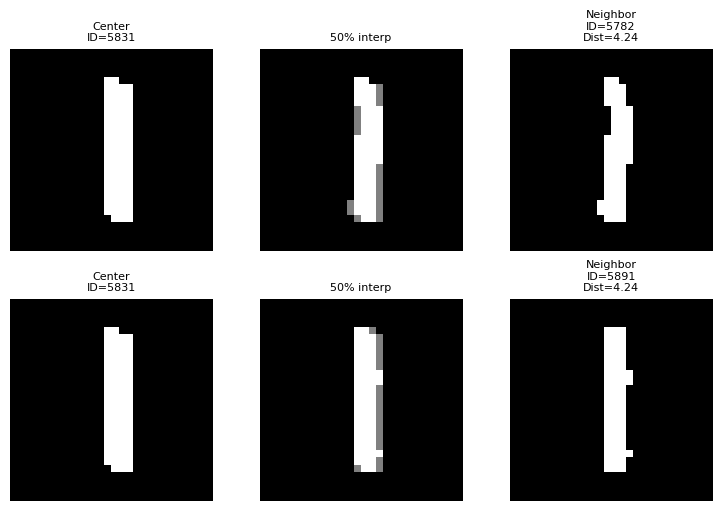

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Assumes g_pruned, vectors_np, and results are already defined in this session.

# 1) Find the largest component
comp  = g_pruned.connected_components()
giant = comp.giant()
giant_ids = set(giant.vs.indices)

# 2) Identify surviving center nodes
center_nodes = set(v for centers in results.values() for v in centers)
eligible     = list(center_nodes & giant_ids)
if not eligible:
    raise RuntimeError("No pruned-center nodes found in the largest component.")

# 3) Pick one center at random
v = random.choice(eligible)
orig_v = g_pruned.vs[v]['orig_idx']
vec_v  = vectors_np[orig_v]
img_v  = vec_v.reshape(28, 28)

# 4) Get neighbors
neighbors = g_pruned.neighbors(v)
n_neighbors = len(neighbors)
if n_neighbors == 0:
    raise RuntimeError("Chosen center has no neighbors in g_pruned.")

# 5) Prepare the plot grid: one row per neighbor, three columns
fig, axes = plt.subplots(n_neighbors, 3,
                         figsize=(3 * 2.5, n_neighbors * 2.5),
                         constrained_layout=True)

# 6) Fill in each row: [center | interpolation | neighbor]
for i, u in enumerate(neighbors):
    orig_u = g_pruned.vs[u]['orig_idx']
    vec_u  = vectors_np[orig_u]
    img_u  = vec_u.reshape(28, 28)
    mid    = 0.5 * (vec_v + vec_u)
    img_mid = mid.reshape(28, 28)
    dist   = np.linalg.norm(vec_v - vec_u)

    # Center column
    ax_center = axes[i, 0] if n_neighbors > 1 else axes[0]
    ax_center.imshow(img_v, cmap='gray')
    ax_center.set_title(f"Center\nID={v}", fontsize=8)
    ax_center.axis('off')

    # Interpolation column
    ax_mid = axes[i, 1] if n_neighbors > 1 else axes[1]
    ax_mid.imshow(img_mid, cmap='gray')
    ax_mid.set_title("50% interp", fontsize=8)
    ax_mid.axis('off')

    # Neighbor column
    ax_nei = axes[i, 2] if n_neighbors > 1 else axes[2]
    ax_nei.imshow(img_u, cmap='gray')
    ax_nei.set_title(f"Neighbor\nID={u}\nDist={dist:.2f}", fontsize=8)
    ax_nei.axis('off')

plt.show()


In [ ]:
from sklearn.neighbors import radius_neighbors_graph
from scipy.sparse import csr_matrix

A = radius_neighbors_graph(
            vectors_np,
            radius=6,
            mode='distance',
            include_self=False
        )
A_csr = csr_matrix(A)

In [ ]:
nbrs = NearestNeighbors(n_neighbors=5).fit(vectors_np)
distances, indices = nbrs.kneighbors(vectors_np)

# 1) create a boolean mask of the same shape
mask = distances < 6

filtered_distances = [d_row[mask_row] for d_row, mask_row in zip(distances, mask)]
filtered_indices   = [i_row[mask_row] for i_row, mask_row in zip(indices,   mask)]

In [ ]:
distances_r, indices_r = nbrs.radius_neighbors(vectors_np, radius=6)

k = 5

top5_distances = [d[:k] for d in distances_r]
top5_indices   = [i[:k] for i in indices_r]

In [ ]:
import numpy as np

# distances is (n_samples, n_neighbors)
max_dists   = distances.max(axis=1)
mask_less   = max_dists < 6
mask_greater = max_dists > 6    # use >= if you want to treat exactly-6 as “greater”

# now slice out your two groups (still as 2D arrays)
distances_less   = distances[mask_less]    # all rows whose max < 6
distances_greater = distances[mask_greater]  # all rows whose max > 6

print(f'Distances less than {distances_less.shape}')
print(f'Distances greater than {distances_greater.shape}')

Distances less than (6595, 5)
Distances greater than (123, 5)


In [ ]:
import numpy as np


'''
not quite an r-net because there is an additional consideration that no landmark is closer to any other landmark than another parameter.
'''
def farthest_first_landmarks(vectors, max_landmarks, max_radius=None, random_state=None):
    """
    Select up to `max_landmarks` landmarks by farthest-first traversal,
    stopping early if the farthest candidate is closer than `max_radius`.

    Parameters
    ----------
    vectors : np.ndarray, shape (n_samples, n_features)
        Data points.
    max_landmarks : int
        Maximum number of landmarks to select.
    max_radius : float or None
        If the current farthest‐first distance is ≤ max_radius, stop early.
    random_state : int or np.random.Generator, optional
        Seed or generator for reproducibility.

    Returns
    -------
    landmarks : List[int]
        Indices of chosen landmarks.
    """
    n, _ = vectors.shape
    rng = np.random.default_rng(random_state)

    first = int(rng.integers(n))
    landmarks = [first]

    diffs = vectors - vectors[first]
    min_dists = np.linalg.norm(diffs, axis=1)

    for _ in range(1, max_landmarks):
        farthest_dist = min_dists.max()
        if max_radius is not None and farthest_dist < max_radius:
            print(f'Breaking because farthest_dist {farthest_dist} < max radius {max_radius}')
            print(min_dists)
            break

        next_idx = int(np.argmax(min_dists))
        landmarks.append(next_idx)

        diffs = vectors - vectors[next_idx]
        d2 = np.linalg.norm(diffs, axis=1)
        min_dists = np.minimum(min_dists, d2)

    return landmarks

max_radius = 5
landmark_idxs = farthest_first_landmarks(vectors_np, max_landmarks=100000, max_radius=max_radius, random_state=42)

# to get the actual vectors:
landmark_vectors = vectors_np[landmark_idxs]

# print("Chosen landmark indices:", landmark_idxs)
print("Their shapes:", landmark_vectors.shape)  # (10, 784) if MNIST



Breaking because farthest_dist 4.898979663848877 < max radius 5
[0.        4.472136  0.        ... 4.7958317 0.        0.       ]
Their shapes: (563, 784)


In [ ]:
from sklearn.neighbors import NearestNeighbors
import igraph as ig

def build_radius_graph(X, radius=6.0):
    """
    Build an undirected radius graph on X where any two points within
    `radius` (Euclidean) are connected by an edge weighted by their distance.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Your landmark vectors (e.g. the output of farthest_first_landmarks).
    radius : float
        The maximum Euclidean distance for an edge.

    Returns
    -------
    g : igraph.Graph
        An undirected graph on n vertices.  g.es['weight'] gives each
        edge’s Euclidean length.
    """
    # find all neighbors within `radius`
    nbrs = NearestNeighbors(radius=radius, metric='euclidean').fit(X)
    distances, indices = nbrs.radius_neighbors(X, return_distance=True)

    edge_list = []
    weight_list = []
    n = X.shape[0]
    for i, (dists, neighs) in enumerate(zip(distances, indices)):
        for j, dist in zip(neighs, dists):
            # undirected: keep only one of (i,j) and (j,i), skip self
            if i < j:
                edge_list.append((i, j))
                weight_list.append(dist)

    g = ig.Graph(n=n, edges=edge_list, directed=False)
    g.es['weight'] = weight_list
    g.vs['orig_idx'] = landmark_idxs
    return g

# usage:
land_vectors = vectors_np[landmark_idxs]  # shape (k,784)
g_radius = build_radius_graph(land_vectors, radius=max_radius+1)
g_radius.vcount(), g_radius.ecount()

(563, 3128)

In [ ]:
# find all connected components
cl = g_radius.clusters()   # or g_pruned.components()

# pair up (component_id, vertex_count)
comp_sizes = list(enumerate(cl.sizes()))
# sort descending by vertex_count
comp_sizes.sort(key=lambda x: x[1], reverse=True)

# print top 10
for comp_id, vcount in comp_sizes[:15]:
    verts = cl[comp_id]              # list of vertex IDs in this component
    subg  = g_radius.subgraph(verts) # induced subgraph
    ecount = subg.ecount()
    print(f"Component {comp_id:2d}: {vcount:5d} vertices, {ecount:5d} edges")


Component  0:   454 vertices,  3117 edges
Component 65:     4 vertices,     3 edges
Component 25:     3 vertices,     3 edges
Component  3:     2 vertices,     1 edges
Component 69:     2 vertices,     1 edges
Component 70:     2 vertices,     1 edges
Component 74:     2 vertices,     1 edges
Component 79:     2 vertices,     1 edges
Component  1:     1 vertices,     0 edges
Component  2:     1 vertices,     0 edges
Component  4:     1 vertices,     0 edges
Component  5:     1 vertices,     0 edges
Component  6:     1 vertices,     0 edges
Component  7:     1 vertices,     0 edges
Component  8:     1 vertices,     0 edges


<ipython-input-19-8c363c8e7cdd>:2: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  cl = g_radius.clusters()   # or g_pruned.components()


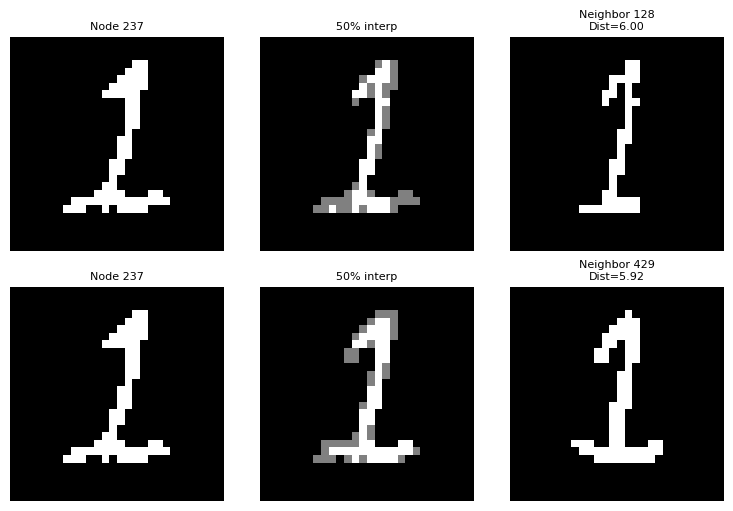

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

def plot_random_radius_interpolations(X, g_radius, random_state=None):
    """
    Pick a random node in the radius graph, then for each neighbor
    plot a row of [node image | 50% interpolation | neighbor image],
    with Euclidean distance in the title.

    Parameters
    ----------
    X : np.ndarray, shape (n_samples, 784)
        The array of landmark vectors you used to build g_radius.
    g_radius : igraph.Graph
        Radius graph built on X; vertices correspond to rows of X.
    random_state : int or None
        Seed for reproducibility.
    """
    rng = np.random.default_rng(random_state)

    # choose a random node that has at least one neighbor
    candidates = [v for v in range(g_radius.vcount()) if g_radius.degree(v) > 0]
    if not candidates:
        raise RuntimeError("No nodes with neighbors found in g_radius.")
    v = rng.choice(candidates)

    # extract vectors
    vec_v = X[v]
    img_v = vec_v.reshape(28, 28)

    neighbors = g_radius.neighbors(v)
    rows = len(neighbors)

    # set up plot: one row per neighbor, three columns
    fig, axes = plt.subplots(rows, 3,
                             figsize=(3 * 2.5, rows * 2.5),
                             constrained_layout=True)

    for i, u in enumerate(neighbors):
        vec_u = X[u]
        img_u = vec_u.reshape(28, 28)
        mid   = 0.5 * (vec_v + vec_u)
        img_m = mid.reshape(28, 28)
        dist  = np.linalg.norm(vec_v - vec_u)

        # handle single row vs multiple
        if rows == 1:
            ax_v, ax_m, ax_u = axes[0], axes[1], axes[2]
        else:
            ax_v = axes[i, 0]
            ax_m = axes[i, 1]
            ax_u = axes[i, 2]

        # center node
        ax_v.imshow(img_v, cmap='gray')
        ax_v.set_title(f"Node {v}", fontsize=8)
        ax_v.axis('off')

        # interpolation
        ax_m.imshow(img_m, cmap='gray')
        ax_m.set_title("50% interp", fontsize=8)
        ax_m.axis('off')

        # neighbor
        ax_u.imshow(img_u, cmap='gray')
        ax_u.set_title(f"Neighbor {u}\nDist={dist:.2f}", fontsize=8)
        ax_u.axis('off')

    plt.show()

# Example usage:
plot_random_radius_interpolations(land_vectors, g_radius)


<ipython-input-21-45f5b961a84a>:7: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  comp  = g_radius.clusters()
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Top 5 explained‐variance ratios: [0.2465462  0.09612799 0.06555346 0.03846855 0.03613496]


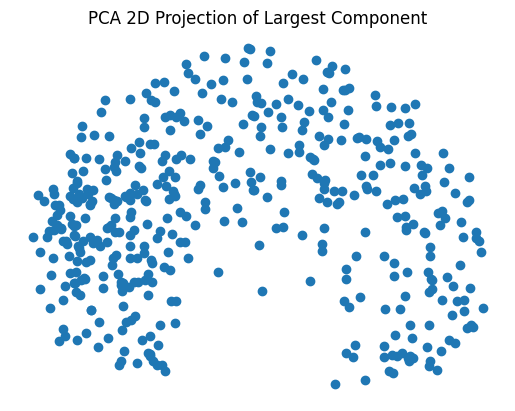

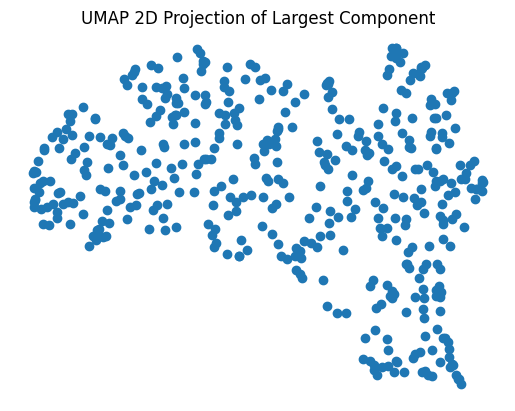

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from umap import UMAP

# --- Identify largest connected component in g_radius ---
comp  = g_radius.clusters()
giant = comp.giant()

# --- Extract the MNIST vectors for those nodes ---
orig_idxs = giant.vs['orig_idx']
X = vectors_np[orig_idxs]  # shape (m, 784)

# --- PCA to 2D ---
pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X)

top5_ratios = pca.explained_variance_ratio_[:5]
print("Top 5 explained‐variance ratios:", top5_ratios)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.title("PCA 2D Projection of Largest Component")
plt.axis('off')

# --- UMAP to 2D ---
umap = UMAP(n_components=2, random_state=42)
X_umap = umap.fit_transform(X)

plt.figure()
plt.scatter(X_umap[:, 0], X_umap[:, 1])
plt.title("UMAP 2D Projection of Largest Component")
plt.axis('off')

plt.show()


In [ ]:
import numpy as np

# 0) Make sure we know each vertex’s original ID in g_radius
g_radius.vs['graph_idx'] = list(range(g_radius.vcount()))

# 1) Find the largest connected component
clust = g_radius.clusters()
giant_id = int(np.argmax(clust.sizes()))
giant_vs = clust[giant_id]            # list of vertex‐IDs in the largest component

# 2) Induce a subgraph on that component
subg = g_radius.subgraph(giant_vs)

# 3) Compute geodesic distances on subgraph
D_geo = np.array(subg.shortest_paths(weights='weight'))  # shape (m, m)

# 4) Gather the original MNIST vectors for these vertices
orig_idxs = subg.vs['orig_idx']       # indices into vectors_np
V = vectors_np[orig_idxs]             # shape (m, 784)

# 5) Compute straight‐line (Euclidean) distances
#    V[:,None,:] has shape (m,1,784), V[None,:,:] is (1,m,784) → diff (m,m,784)
D_euc = np.linalg.norm(V[:, None, :] - V[None, :, :], axis=2)

# 6) Compute the “stretch” = geo − euclid, and find the max over i<j
m = subg.vcount()
iu, ju = np.triu_indices(m, k=1)
stretch = D_geo[iu, ju] - D_euc[iu, ju]
# 3) Identify top 5 stretches
topk = 10
# argsort in descending order
top_idxs = np.argsort(stretch)[-topk:][::-1]

print("Top 5 node pairs by stretch (geodesic - euclidean):\n")
for rank, idx in enumerate(top_idxs, start=1):
    i, j = iu[idx], ju[idx]
    geo = D_geo[i, j]
    euc = D_euc[i, j]
    s   = stretch[idx]
    node_i = subg.vs[i]['graph_idx']
    node_j = subg.vs[j]['graph_idx']
    print(f"{rank}. Nodes {node_i} - {node_j}:")
    print(f"     Geodesic = {geo:.4f}, Euclidean = {euc:.4f}, Stretch = {s:.4f}\n")

<ipython-input-22-61a4f79fa243>:7: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  clust = g_radius.clusters()
<ipython-input-22-61a4f79fa243>:15: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  D_geo = np.array(subg.shortest_paths(weights='weight'))  # shape (m, m)


Top 5 node pairs by stretch (geodesic - euclidean):

1. Nodes 79 - 239:
     Geodesic = 75.1378, Euclidean = 10.5357, Stretch = 64.6022

2. Nodes 197 - 239:
     Geodesic = 74.7056, Euclidean = 10.3923, Stretch = 64.3133

3. Nodes 79 - 219:
     Geodesic = 74.0003, Euclidean = 12.4097, Stretch = 61.5906

4. Nodes 197 - 219:
     Geodesic = 73.5681, Euclidean = 12.1244, Stretch = 61.4437

5. Nodes 4 - 79:
     Geodesic = 74.0814, Euclidean = 12.8452, Stretch = 61.2362

6. Nodes 4 - 197:
     Geodesic = 73.6492, Euclidean = 12.8062, Stretch = 60.8429

7. Nodes 79 - 137:
     Geodesic = 73.1780, Euclidean = 12.9228, Stretch = 60.2551

8. Nodes 137 - 197:
     Geodesic = 72.7457, Euclidean = 12.8062, Stretch = 59.9395

9. Nodes 239 - 320:
     Geodesic = 69.1378, Euclidean = 10.0499, Stretch = 59.0880

10. Nodes 79 - 410:
     Geodesic = 70.3731, Euclidean = 11.7047, Stretch = 58.6684



In [ ]:
# sort all pairs by descending stretch
sorted_idx = np.argsort(stretch)[::-1]

print("Node pairs with stretch ≥ 6:\n")
for rank, idx in enumerate(sorted_idx, start=1):
    s = stretch[idx]
    if s < 6.0:
        print(f"{rank}. Nodes {node_i} - {node_j}:")
        print(f"     Geodesic = {geo:.4f}, Euclidean = {euc:.4f}, Stretch = {s:.4f}\n")
        break
    i, j = iu[idx], ju[idx]
    geo = D_geo[i, j]
    euc = D_euc[i, j]
    node_i = subg.vs[i]['graph_idx']
    node_j = subg.vs[j]['graph_idx']


Node pairs with stretch ≥ 6:

85232. Nodes 292 - 500:
     Geodesic = 15.6803, Euclidean = 8.8318, Stretch = 5.8333



In [ ]:
from collections import Counter

# `stretch`, `iu`, `ju` already computed as before
mask = stretch >= 6.0

# count each time a node appears in a high-stretch pair
freq = Counter()
for i, j in zip(iu[mask], ju[mask]):
    gi = subg.vs[i]['graph_idx']
    gj = subg.vs[j]['graph_idx']
    freq[gi] += 1
    freq[gj] += 1

print("Top 10 nodes by number of ≥6-unit detours:")
for node, count in freq.most_common(10):
    print(f"  Node {node:4d}: {count} pairs")


Top 10 nodes by number of ≥6-unit detours:
  Node   64: 451 pairs
  Node  159: 451 pairs
  Node  240: 451 pairs
  Node  270: 451 pairs
  Node   79: 450 pairs
  Node  197: 450 pairs
  Node  200: 450 pairs
  Node  249: 450 pairs
  Node  266: 450 pairs
  Node  173: 449 pairs


In [ ]:
import igraph as ig

# build a graph on the m subgraph‐vertices, with edges for each high‐stretch pair
m = subg.vcount()
edges = [(i, j) for i, j, s in zip(iu, ju, stretch) if s >= 33]
g_folds = ig.Graph(n=m, edges=edges, directed=False)

# find connected regions of folding
fold_comps = g_folds.clusters()
sizes = sorted(fold_comps.sizes(), reverse=True)
print("Sizes of the top 5 folded regions:", sizes[:5])


Sizes of the top 5 folded regions: [435, 1, 1, 1, 1]


<ipython-input-25-900c7695cddc>:9: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  fold_comps = g_folds.clusters()


<ipython-input-26-03b91012164a>:5: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  clust  = g_radius.clusters()
<ipython-input-26-03b91012164a>:9: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  D_geo = np.array(giant.shortest_paths(weights='weight'))


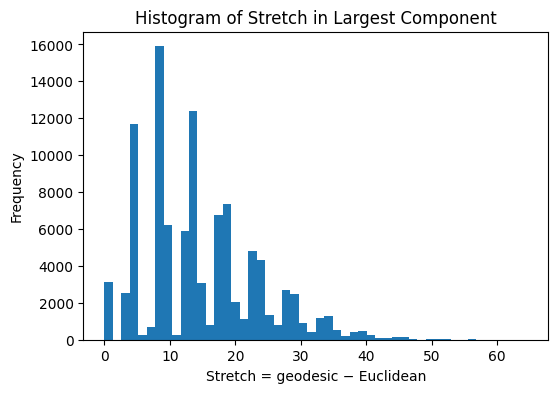

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Extract the largest connected component of g_radius
clust  = g_radius.clusters()
giant  = clust.giant()

# 2) Compute geodesic distance matrix on that subgraph
D_geo = np.array(giant.shortest_paths(weights='weight'))

# 3) Pull out the original MNIST vectors and compute Euclidean distances
orig_idxs = giant.vs['orig_idx']
V = vectors_np[orig_idxs]  # shape (m, 784)
D_euc = np.linalg.norm(V[:, None, :] - V[None, :, :], axis=2)

# 4) Flatten upper-triangle into a 1D “stretch” array
m = giant.vcount()
iu, ju = np.triu_indices(m, k=1)
stretch = D_geo[iu, ju] - D_euc[iu, ju]

# 5) Plot histogram
plt.figure(figsize=(6,4))
plt.hist(stretch, bins=50)
plt.xlabel('Stretch = geodesic − Euclidean')
plt.ylabel('Frequency')
plt.title('Histogram of Stretch in Largest Component')
plt.show()


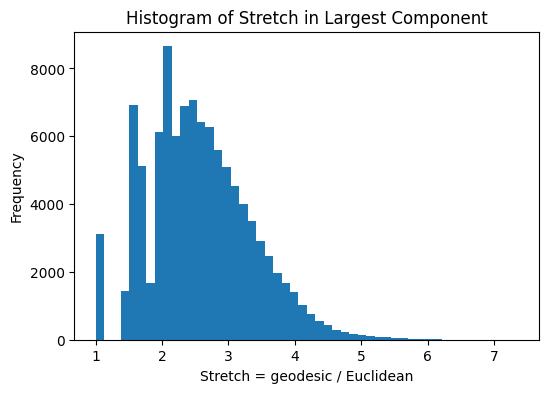

In [ ]:
stretch = D_geo[iu, ju] / D_euc[iu, ju]

# 5) Plot histogram
plt.figure(figsize=(6,4))
plt.hist(stretch, bins=50)
plt.xlabel('Stretch = geodesic / Euclidean')
plt.ylabel('Frequency')
plt.title('Histogram of Stretch in Largest Component')
plt.show()

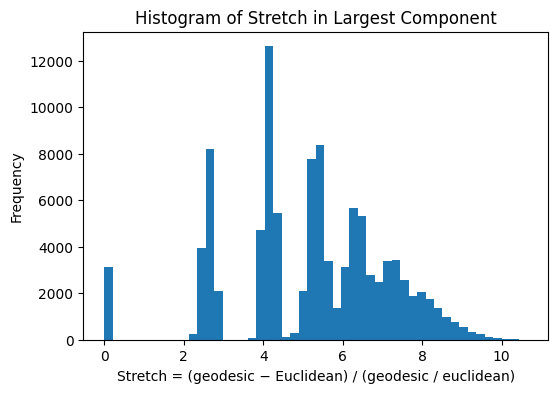

In [ ]:
stretch = (D_geo[iu, ju] - D_euc[iu, ju]) / (D_geo[iu, ju] / D_euc[iu, ju])

# 5) Plot histogram
plt.figure(figsize=(6,4))
plt.hist(stretch, bins=50)
plt.xlabel('Stretch = (geodesic − Euclidean) / (geodesic / euclidean)')
plt.ylabel('Frequency')
plt.title('Histogram of Stretch in Largest Component')
plt.show()

In [ ]:
import numpy as np
import igraph as ig
from numpy.linalg import norm

def iterative_unfold_landmarks_full(land_vectors: np.ndarray,
                                    radius: float = 6.0,
                                    n_iters: int = 3):
    """
    Iteratively peel off the manifold’s most curved axes using full residual vectors.

    Parameters
    ----------
    land_vectors : (N, D) array
        Your landmark vectors (e.g. selected via farthest-first).
    radius : float
        Euclidean radius threshold for connecting points in each graph.
    n_iters : int
        Number of axes (iterations) to extract.

    Returns
    -------
    axes : List[ (int, int) ]
        The index‐pairs (i, j) chosen at each iteration.
    residuals : np.ndarray, shape (N, D)
        The final residual vectors after all iterations.
    """
    # Initialize
    current = land_vectors.copy()   # shape (N, D)
    N, D = current.shape
    axes = []

    for it in range(n_iters):
        # 1) Build a brute‐force radius‐graph on current residual vectors
        edges, weights = [], []
        for i in range(N):
            for j in range(i+1, N):
                d = norm(current[i] - current[j])
                if d <= radius:
                    edges.append((i, j))
                    weights.append(d)
        g = ig.Graph(n=N, edges=edges, directed=False)
        g.es['weight'] = weights

        # 2) Restrict to the largest connected component
        comp  = g.clusters()
        giant = comp.giant()
        m     = giant.vcount()
        if m < 2:
            print(f"Stopping at iteration {it}: component too small.")
            break

        # Map subgraph indices → original indices
        idx_map = np.array(giant.vs.indices)  # length m

        # 3) Compute geodesic distance matrix on the giant component
        D_geo = np.array(giant.shortest_paths(weights='weight'))

        # 4) Compute Euclidean distance matrix on the same points
        X = current[idx_map]                 # (m, D)
        D_euc = np.zeros((m, m))
        for i in range(m):
            for j in range(m):
                D_euc[i, j] = norm(X[i] - X[j])

        # 5) Flatten upper‐triangle and find max‐stretch pair
        iu, ju  = np.triu_indices(m, k=1)
        # stretch = D_geo[iu, ju] - D_euc[iu, ju]
        # stretch = (D_geo[iu, ju] - D_euc[iu, ju])/(D_geo[iu, ju] / D_euc[iu, ju])
        stretch = D_euc[iu, ju]
        arg     = np.argmax(stretch)
        i0, j0  = iu[arg], ju[arg]
        global_i, global_j = int(idx_map[i0]), int(idx_map[j0])
        axes.append((global_i, global_j))
        print(f"Iter {it}: axis = ({global_i},{global_j}), stretch = {stretch[arg]:.4f}")

        # 6) Compute full residual vectors off that axis
        A      = current[global_i]
        B      = current[global_j]
        axis   = B - A
        axis_u = axis / norm(axis)
        # project each point onto AB
        t      = (current - A) @ axis_u                 # (N,)
        proj   = A + np.outer(t, axis_u)                # (N, D)
        residuals = current - proj                      # (N, D)

        # 7) Prepare for next iteration
        current = residuals

    return axes, residuals

# Example usage:
land_vectors = vectors_np[landmark_idxs]
axes, final_residuals = iterative_unfold_landmarks_full(land_vectors,
                                                        radius=6.0,
                                                        n_iters=25)
print("Extracted axes (landmark indices):", axes)


<ipython-input-29-e30c9b2e8327>:45: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  comp  = g.clusters()
<ipython-input-29-e30c9b2e8327>:56: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  D_geo = np.array(giant.shortest_paths(weights='weight'))


Iter 0: axis = (1,4), stretch = 15.2971
Iter 1: axis = (2,25), stretch = 13.4449
Iter 2: axis = (3,5), stretch = 12.9342
Iter 3: axis = (9,10), stretch = 12.5297
Iter 4: axis = (27,33), stretch = 12.2149
Iter 5: axis = (11,48), stretch = 11.8470
Iter 6: axis = (24,89), stretch = 11.5928
Iter 7: axis = (17,191), stretch = 11.2614
Iter 8: axis = (15,250), stretch = 10.7664
Iter 9: axis = (63,219), stretch = 10.5715
Iter 10: axis = (43,117), stretch = 10.3928
Iter 11: axis = (28,160), stretch = 10.3309
Iter 12: axis = (7,216), stretch = 10.2051
Iter 13: axis = (12,74), stretch = 9.9940
Iter 14: axis = (42,249), stretch = 9.8979
Iter 15: axis = (122,370), stretch = 9.7103
Iter 16: axis = (53,140), stretch = 9.4784
Iter 17: axis = (130,295), stretch = 9.3968
Iter 18: axis = (8,44), stretch = 9.3801
Iter 19: axis = (69,93), stretch = 9.2545
Iter 20: axis = (37,65), stretch = 9.1506
Iter 21: axis = (30,107), stretch = 9.0038
Iter 22: axis = (22,114), stretch = 8.9534
Iter 23: axis = (54,550),

<ipython-input-30-71aa445469f1>:41: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  D_geo = np.array(giant.shortest_paths(weights='weight'))


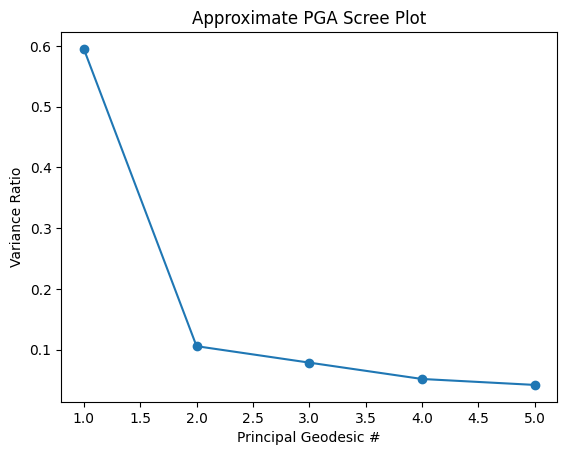

Explained variance ratios: [0.59510672 0.10585032 0.0787666  0.05186318 0.0420796 ]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from sklearn.decomposition import PCA

# --- assume D_geo (m×m geodesic distance matrix on the largest component) is defined ---
# and orig_idxs gives the mapping from subgraph indices → vectors_np rows

def approximate_pga(D_geo, n_components=5, mds_init=2):
    """
    Approximate Principal Geodesic Analysis by:
      1) Embedding via classical MDS on geodesic distances.
      2) Running PCA on the MDS embedding.

    Parameters
    ----------
    D_geo : np.ndarray, shape (m, m)
        Geodesic (shortest-path) distance matrix on your points.
    n_components : int
        How many principal geodesics (axes) to extract.
    mds_init : int
        Number of dimensions for the MDS initial embedding.

    Returns
    -------
    pca : fitted PCA instance on the MDS embedding
    Y : np.ndarray, shape (m, mds_init)
        The MDS embedding of your points.
    """
    # 1) MDS embedding
    mds = MDS(n_components=mds_init, dissimilarity='precomputed', random_state=42)
    Y   = mds.fit_transform(D_geo)

    # 2) PCA on the MDS embedding
    pca = PCA(n_components=n_components, random_state=42)
    pca.fit(Y)

    return pca, Y

# Example usage:
D_geo = np.array(giant.shortest_paths(weights='weight'))
pca, Y = approximate_pga(D_geo, n_components=5, mds_init=10)

# Scree plot of PCA eigenvalues on the manifold
plt.figure()
plt.plot(np.arange(1, 6), pca.explained_variance_ratio_, 'o-')
plt.xlabel('Principal Geodesic #')
plt.ylabel('Variance Ratio')
plt.title('Approximate PGA Scree Plot')
plt.show()

# Print top eigenvalues
print("Explained variance ratios:", pca.explained_variance_ratio_)


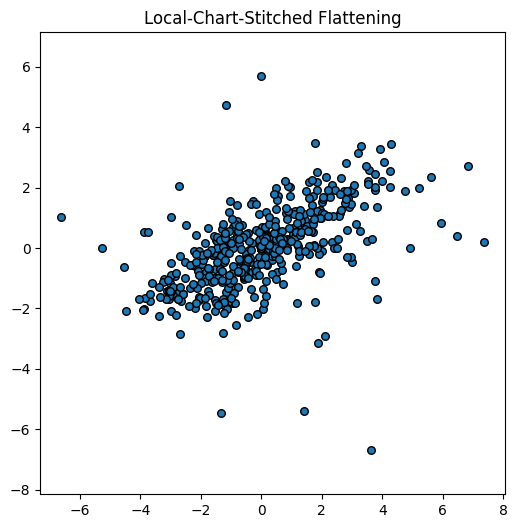

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assumes land_vectors (shape N×D) and g_radius (igraph on land_vectors) are defined
X = land_vectors  # shape (N, D)
N, D = X.shape

# 1) Build neighbor lists from the radius-graph
neighbors = [g_radius.neighbors(i) for i in range(N)]

# 2) Compute local 2D tangent planes via PCA for each node
P_list = []
for i, nbrs in enumerate(neighbors):
    if len(nbrs) < 2:
        # Not enough neighbors to define a plane
        P_list.append(None)
        continue
    diffs = X[nbrs] - X[i]                   # (|nbrs|, D)
    pca = PCA(n_components=2, random_state=42).fit(diffs)
    P_list.append(pca.components_.T)         # (D × 2)

# 3) Assemble a global linear system A·y = b to stitch charts
#    Unknown y is stacked [Y_0_x, Y_0_y, Y_1_x, Y_1_y, ..., Y_{N-1}_x, Y_{N-1}_y]
#    For each edge i→j we impose:
#      Y_j - Y_i ≈ P_i^T · (X_j - X_i)

# Count total equations: 2 per edge (x and y)
n_eqs = sum(2 * len(nbrs) for nbrs in neighbors)
A = np.zeros((n_eqs, 2 * N))
b = np.zeros(n_eqs)

row = 0
for i, nbrs in enumerate(neighbors):
    P_i = P_list[i]
    if P_i is None:
        continue
    for j in nbrs:
        # Project the high‑D difference onto node‑i's tangent plane
        dX = X[j] - X[i]                    # (D,)
        proj = P_i.T.dot(dX)               # (2,)

        # Equation for x‑coordinate
        A[row, 2*j]   =  1
        A[row, 2*i]   = -1
        b[row]        = proj[0]
        row += 1

        # Equation for y‑coordinate
        A[row, 2*j+1] =  1
        A[row, 2*i+1] = -1
        b[row]        = proj[1]
        row += 1

# 4) Solve the least-squares problem to get 2D coordinates
y, *_ = np.linalg.lstsq(A, b, rcond=None)
Y = y.reshape(N, 2)

# 5) Plot the result
plt.figure(figsize=(6,6))
plt.scatter(Y[:,0], Y[:,1], s=30, edgecolor='k')
plt.title("Local‐Chart‐Stitched Flattening")
plt.axis('equal')
plt.show()


In [ ]:
import numpy as np
from sklearn.decomposition import PCA

# --- Assumes land_vectors (X), g_radius, and stitched embedding Y are defined ---
# X: (N, D) array of original landmark vectors
# g_radius: igraph.Graph on N vertices with edges based on radius
# Y: (N, 2) array of 2D coordinates from local-chart stitching

N, D = X.shape

# 1) Compute average local PCA variance-explained
local_vars = []
for i in range(N):
    nbrs = g_radius.neighbors(i)
    if len(nbrs) < 2:
        continue
    diffs = X[nbrs] - X[i]
    pca = PCA(n_components=2).fit(diffs)
    local_vars.append(pca.explained_variance_ratio_.sum())

avg_local_variance = np.mean(local_vars) if local_vars else np.nan

# 2) Compute global stress on radius-graph edges
stress_num = 0.0
stress_den = 0.0

for e in g_radius.es:
    i, j = e.tuple
    d_orig = np.linalg.norm(X[i] - X[j])
    d_emb  = np.linalg.norm(Y[i] - Y[j])
    stress_num += (d_emb - d_orig)**2
    stress_den += d_orig**2  # normalization

stress_relative = stress_num / stress_den if stress_den > 0 else np.nan

# Display results
print(f"Average local 2D variance explained by tangent PCA: {avg_local_variance:.3f}")
print(f"Global normalized stress on edges: {stress_relative:.3f}")


Average local 2D variance explained by tangent PCA: 0.459
Global normalized stress on edges: 0.654


In [ ]:
import numpy as np
import random

# assume g_largest and vectors_np are in scope

# 1) pick a random vertex in g_largest
v = random.choice(range(g_radius.vcount()))

# 2) look up its original MNIST vector
orig_v = g_radius.vs[v]['orig_idx']
X_v    = vectors_np[orig_v]         # shape (784,)

# 3) get its neighbors
nbrs = g_radius.neighbors(v)
if not nbrs:
    print("Chosen node has no neighbors.")
else:
    # 4) gather their original vectors
    orig_idxs = [g_radius.vs[u]['orig_idx'] for u in nbrs]
    X_nb      = vectors_np[orig_idxs]  # shape (k,784)

    # 5) compute the direction vectors and normalize
    diffs     = X_nb - X_v             # shape (k,784)
    norms     = np.linalg.norm(diffs, axis=1, keepdims=True)  # (k,1)
    dirs_unit = diffs / norms          # (k,784)

    # 6) print out a few directions
    print(f"Center node: {v} (orig idx {orig_v}), has {len(nbrs)} neighbors\n")
    for i, u in enumerate(nbrs):
        print(f"Neighbor {u} → unit‐direction vector (first 5 entries): {dirs_unit[i,:5]}")


Center node: 231 (orig idx 4097), has 28 neighbors

Neighbor 0 → unit‐direction vector (first 5 entries): [0. 0. 0. 0. 0.]
Neighbor 134 → unit‐direction vector (first 5 entries): [0. 0. 0. 0. 0.]
Neighbor 206 → unit‐direction vector (first 5 entries): [0. 0. 0. 0. 0.]
Neighbor 265 → unit‐direction vector (first 5 entries): [0. 0. 0. 0. 0.]
Neighbor 272 → unit‐direction vector (first 5 entries): [0. 0. 0. 0. 0.]
Neighbor 298 → unit‐direction vector (first 5 entries): [0. 0. 0. 0. 0.]
Neighbor 299 → unit‐direction vector (first 5 entries): [0. 0. 0. 0. 0.]
Neighbor 333 → unit‐direction vector (first 5 entries): [0. 0. 0. 0. 0.]
Neighbor 340 → unit‐direction vector (first 5 entries): [0. 0. 0. 0. 0.]
Neighbor 344 → unit‐direction vector (first 5 entries): [0. 0. 0. 0. 0.]
Neighbor 356 → unit‐direction vector (first 5 entries): [0. 0. 0. 0. 0.]
Neighbor 373 → unit‐direction vector (first 5 entries): [0. 0. 0. 0. 0.]
Neighbor 380 → unit‐direction vector (first 5 entries): [0. 0. 0. 0. 0.]
N

In [ ]:
import numpy as np
import random
from sklearn.decomposition import PCA

# 1) Pick a random node in g_radius and compute neighbor directions
v = random.randrange(g_radius.vcount())
orig_v = g_radius.vs[v]['orig_idx']
X_v    = vectors_np[orig_v]  # the 784-vector for node v

nbrs   = g_radius.neighbors(v)
if not nbrs:
    raise RuntimeError(f"Node {v} has no neighbors in g_radius.")

# Gather difference vectors (directions) from v to each neighbor
X_nb  = vectors_np[[g_radius.vs[u]['orig_idx'] for u in nbrs]]  # shape (k, 784)
diffs = X_nb - X_v                                               # shape (k, 784)

# 2) Use SVD to find the exact subspace rank
U, s, Vt = np.linalg.svd(diffs, full_matrices=False)
tol  = 1e-6
rank = np.sum(s > tol)
axes_svd = Vt[:rank]   # each row is one orthonormal basis vector in R^784

# 3) Or use PCA to see cumulative variance explained
pca      = PCA().fit(diffs)
cumvar   = np.cumsum(pca.explained_variance_ratio_)
n_axes   = np.searchsorted(cumvar, 0.999999) + 1
axes_pca = pca.components_[:n_axes]

print(f"Random node {v} (orig idx {orig_v}), {len(nbrs)} neighbors")
print(f"SVD subspace rank: {rank} axes needed for exact span")
print(f"PCA axes for ~100% variance: {n_axes}")


Random node 463 (orig idx 6159), 7 neighbors
SVD subspace rank: 7 axes needed for exact span
PCA axes for ~100% variance: 6


In [ ]:
import numpy as np
import random
from sklearn.decomposition import PCA

# Helper: compute neighbor-difference vectors in the given graph
def directions_of(node, graph, vectors_np):
    nbrs = graph.neighbors(node)
    if not nbrs:
        return np.zeros((0, vectors_np.shape[1]))
    orig_v = graph.vs[node]['orig_idx']
    X_v = vectors_np[orig_v]
    orig_idxs_nb = [graph.vs[u]['orig_idx'] for u in nbrs]
    X_nb = vectors_np[orig_idxs_nb]
    return X_nb - X_v

# Helper: PCA axes needed for a given variance threshold
def pca_axes_needed(diffs, var_thresh=0.999999):
    if diffs.size == 0:
        return 0, np.empty((0, diffs.shape[1]))
    pca = PCA().fit(diffs)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_axes = np.searchsorted(cumvar, var_thresh) + 1
    return n_axes, pca.components_[:n_axes]

# 0) Extract the largest connected component of g_radius
comp = g_radius.connected_components()
subg = comp.giant()

# 1) Pick a random center in the largest component
v = random.randrange(subg.vcount())
d_v, _ = pca_axes_needed(directions_of(v, subg, vectors_np))
print(f"Node {v}: needs {d_v} PCA axes") #for its {len(subg.neighbors(v))} directions")

# 2) Pick a random neighbor of v (within subg)
nbrs = subg.neighbors(v)
if nbrs:
    u = random.choice(nbrs)
    d_u, _ = pca_axes_needed(directions_of(u, subg, vectors_np))
    print(f"Neighbor {u}: needs {d_u} PCA axes")# for its {len(subg.neighbors(u))} directions")
else:
    print("No neighbor to pick for step 2")

# 3) Combine both sets and measure axes needed
diffs_v = directions_of(v, subg, vectors_np)
diffs_u = directions_of(u, subg, vectors_np) if nbrs else np.zeros((0, vectors_np.shape[1]))
diffs_all = np.vstack([diffs_v, diffs_u]) if diffs_v.size + diffs_u.size > 0 else diffs_v
d_all, _ = pca_axes_needed(diffs_all, var_thresh=0.999999)
print(f"Combined set needs {d_all} PCA axes")


Node 136: needs 1 PCA axes
Neighbor 322: needs 6 PCA axes
Combined set needs 7 PCA axes


In [ ]:
import numpy as np
import random
from sklearn.decomposition import PCA

# Helper to get difference vectors from a node to its neighbors
def directions_of(node, graph, vectors_np):
    nbrs = graph.neighbors(node)
    if not nbrs:
        return np.zeros((0, vectors_np.shape[1]))
    X0 = vectors_np[graph.vs[node]['orig_idx']]
    Xn = vectors_np[[graph.vs[u]['orig_idx'] for u in nbrs]]
    return Xn - X0

# Helper to compute how many PCA axes capture ~100% variance
def pca_axes_needed(diffs, var_thresh=0.999999):
    if diffs.size == 0:
        return 0
    pca = PCA().fit(diffs)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    return np.searchsorted(cumvar, var_thresh) + 1

# 1) Extract the largest connected component of g_radius
comp = g_radius.connected_components()
subg = comp.giant()

# 2) Pick a random center node in that component
v = random.randrange(subg.vcount())
nbrs = subg.neighbors(v)

# 3) PCA for the center node
diffs_v = directions_of(v, subg, vectors_np)
n_axes_v = pca_axes_needed(diffs_v)
print(f"Center node {v} has {len(nbrs)} neighbors.")
print(f"PCA needs {n_axes_v} axes to capture ~100% of variance in those {len(nbrs)} directions.\n")

# 4) PCA for each neighbor node
print("Neighbor | #Neighbors | PCA Axes Needed")
for u in nbrs:
    nbrs_u = subg.neighbors(u)
    diffs_u = directions_of(u, subg, vectors_np)
    n_axes_u = pca_axes_needed(diffs_u)
    print(f"{u:8d} | {len(nbrs_u):10d} | {n_axes_u:15d}")


Center node 196 has 17 neighbors.
PCA needs 16 axes to capture ~100% of variance in those 17 directions.

Neighbor | #Neighbors | PCA Axes Needed
      62 |          2 |               1
      87 |          5 |               4
     134 |         29 |              28
     150 |         10 |               9
     165 |         19 |              18
     242 |         18 |              17
     246 |          3 |               2
     269 |         20 |              19
     284 |         19 |              18
     314 |         16 |              15
     334 |         27 |              26
     350 |         30 |              29
     379 |         19 |              18
     380 |         16 |              15
     394 |         32 |              31
     396 |         27 |              26
     445 |         24 |              23


In [ ]:
import numpy as np
from sklearn.decomposition import PCA

# 1) Extract the largest connected component of g_radius
comp  = g_radius.clusters()
giant = comp.giant()

# 2) Gather the corresponding vectors
orig_idxs = giant.vs['orig_idx']
X = vectors_np[orig_idxs]   # shape (m, D)

# 3) Fit PCA and compute cumulative variance ratio
pca   = PCA().fit(X)
cumvar = np.cumsum(pca.explained_variance_ratio_)

# 4) Find how many components explain ≥99.999% of the variance
threshold = 0.99999
n_axes = np.searchsorted(cumvar, threshold) + 1

print(f"{n_axes} PCA axes explain ≥{threshold*100:.3f}% of variance")


358 PCA axes explain ≥99.999% of variance


<ipython-input-37-602257ef7a1e>:5: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  comp  = g_radius.clusters()


Center node 315 (orig idx 5526)


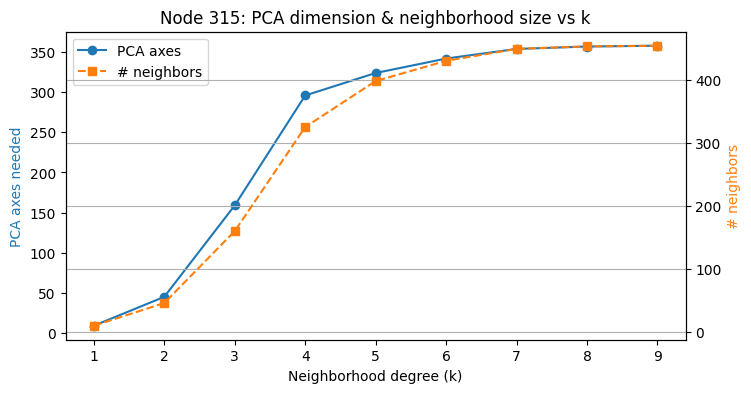

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

threshold = 0.99999

# 1) Largest connected component
comp = g_radius.connected_components()
subg = comp.giant()
m    = subg.vcount()

# 2) Pick a random center
v = random.randrange(m)
print(f"Center node {v} (orig idx {subg.vs[v]['orig_idx']})")

degrees       = []
axes_needed   = []
neigh_counts  = []

for k in range(1, m):
    neighs = subg.neighborhood([v], order=k, mindist=0)[0]
    neigh_counts.append(len(neighs))

    X_k = vectors_np[[subg.vs[i]['orig_idx'] for i in neighs]]
    pca = PCA().fit(X_k)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_axes = np.searchsorted(cumvar, threshold) + 1

    degrees.append(k)
    axes_needed.append(n_axes)

    if len(neighs) == m:
        break

# 3) Plot with twin y-axis
fig, ax1 = plt.subplots(figsize=(8,4))
ax2 = ax1.twinx()

ax1.plot(degrees, axes_needed, '-o', color='tab:blue', label='PCA axes')
ax2.plot(degrees, neigh_counts, '--s', color='tab:orange', label='# neighbors')

ax1.set_xlabel('Neighborhood degree (k)')
ax1.set_ylabel('PCA axes needed', color='tab:blue')
ax2.set_ylabel('# neighbors',    color='tab:orange')

# Optional: show a legend combining both
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines+lines2, labels+labels2, loc='upper left')

plt.title(f'Node {v}: PCA dimension & neighborhood size vs k')
plt.grid(True)
plt.show()


In [ ]:
import numpy as np

# 1) Restrict to the largest connected component of g_radius
comp   = g_radius.connected_components()
subg   = comp.giant()
orig_idxs = subg.vs['orig_idx']            # indices into vectors_np
L      = vectors_np[orig_idxs]            # (M, 784) landmark vectors in the giant

# 2) Geodesic distance matrix on subgraph
D_geo = np.array(subg.shortest_paths(weights='weight'))  # (M, M)

# 3) Straight‐line (Euclidean) distance matrix on those same vectors
diffs = L[:, None, :] - L[None, :, :]     # (M, M, 784)
D_euc = np.linalg.norm(diffs, axis=2)     # (M, M)

# 4) Extra‐flips matrix: clamp any negatives to zero
extra_flips = np.clip(D_geo - D_euc, a_min=0, a_max=None)  # (M, M)


<ipython-input-39-ffa0480ff528>:10: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  D_geo = np.array(subg.shortest_paths(weights='weight'))  # (M, M)


In [ ]:
import numpy as np

# 1) Assume you’ve already restricted to the largest component `subg`
#    and computed:
#      D_geo       = np.array(subg.shortest_paths(weights='weight'))  # (M, M)
#      D_euc       = ...                                              # (M, M)
#      extra_flips = np.clip(D_geo - D_euc, a_min=0, a_max=None)      # (M, M)

M = subg.vcount()

# 2) Prepare to loop the upper triangle
iu, ju = np.triu_indices(M, k=1)

# 3) Initialize edge_load for each edge in subg
edge_load = np.zeros(subg.ecount(), dtype=float)

# 4) Accumulate detour “flow” onto each shortest-path edge
for i, j in zip(iu, ju):
    s = extra_flips[i, j]
    if s <= 0:
        continue
    # fetch the unique shortest path (sequence of vertex indices)
    path = subg.get_shortest_paths(i, to=j, weights='weight', mode='ALL')[0]
    # add this detour value to each edge along that path
    for u, v in zip(path[:-1], path[1:]):
        eid = subg.get_eid(u, v)   # undirected edge id
        edge_load[eid] += s

# 5) (optional) store back on the graph
subg.es['load'] = edge_load

# Now `edge_load[e]` is the total “wasted‐flips” load carried by edge e.


In [ ]:
import numpy as np

# assume subg is your igraph.Graph for the largest component, with es['load'] defined
edge_load = np.array(subg.es['load'], dtype=float)
E = subg.ecount()

# build adjacency: for each edge, list edge‐ids that share a vertex
edge_adj = []
for eid in range(E):
    v1, v2 = subg.es[eid].tuple
    # incident edges on either endpoint
    neigh = set(subg.incident(v1)) | set(subg.incident(v2))
    edge_adj.append(np.fromiter(neigh, dtype=int))

# define blur radii and perform Jacobi sweeps
radii = [0, 1, 2, 4, 8, 16]
lambdas = {}

for r in radii:
    values = edge_load.copy()
    for sweep in range(r):
        new_vals = np.zeros_like(values)
        for eid, nbrs in enumerate(edge_adj):
            idxs = np.concatenate(([eid], nbrs))
            new_vals[eid] = values[idxs].mean()

        values = new_vals
    lambdas[r] = values

# store back onto the graph as edge attributes: 'lambda_0', 'lambda_1', ...
for r, vals in lambdas.items():
    subg.es[f'lambda_{r}'] = vals

# Now subg.es['lambda_0'], subg.es['lambda_1'], ..., 'lambda_8' hold the blurred loads.


In [ ]:
import numpy as np

# Assumes `subg` (igraph.Graph), `edge_adj` (list of neighbor-edge-ID arrays),
# and `lambdas` (dict mapping radius->blurred edge-load arrays) are defined.

patches_by_radius = {}

for r, values in lambdas.items():
    # 1) Compute the 90th-percentile threshold
    thresh = np.percentile(values, 90)

    # 2) Identify core edges: local maxima above threshold
    cores = [
        eid for eid in range(len(values))
        if values[eid] >= thresh and all(values[eid] >= values[nbr] for nbr in edge_adj[eid])
    ]

    # 3) Flood-fill patches from each core
    visited = set()
    patches = []
    for core in cores:
        if core in visited:
            continue
        patch = {core}
        stack = [core]
        while stack:
            e = stack.pop()
            for nbr in edge_adj[e]:
                if nbr not in patch and values[nbr] >= thresh:
                    patch.add(nbr)
                    stack.append(nbr)
        visited |= patch
        patches.append(patch)

    patches_by_radius[r] = patches

# Example: print the number and sizes of patches for each blur radius
for r, patches in patches_by_radius.items():
    sizes = sorted([len(p) for p in patches], reverse=True)
    print(f"Radius {r}: {len(patches)} patches; top sizes = {sizes[:5]}")


Radius 0: 6 patches; top sizes = [304, 3, 2, 1, 1]
Radius 1: 7 patches; top sizes = [300, 4, 4, 1, 1]
Radius 2: 5 patches; top sizes = [307, 2, 1, 1, 1]
Radius 4: 4 patches; top sizes = [285, 18, 7, 2]
Radius 8: 5 patches; top sizes = [293, 14, 2, 2, 1]
Radius 16: 4 patches; top sizes = [293, 10, 6, 3]


In [ ]:
# Assume `patches_by_radius` is your dict: radius → list of patches (each a set of edge‐IDs)

# 1) Sort blur levels from sharpest (smallest r) to blurriest (largest r)
levels = sorted(patches_by_radius.keys())

# 2) Create a node‐record for every patch
#    Keyed by (radius, patch_index), storing its edge‐set and a list of children
tree = {}
for r in levels:
    for idx, patch in enumerate(patches_by_radius[r]):
        tree[(r, idx)] = {
            'edges': set(patch),
            'children': []
        }

# 3) Link each patch at level r to all sharper patches whose edges lie inside it
for i, r in enumerate(levels):
    if i == 0:
        continue   # no sharper level than the first
    # all sharper levels are levels[:i]
    for idx, patch in enumerate(patches_by_radius[r]):
        parent_id = (r, idx)
        parent_edges = tree[parent_id]['edges']
        # find children among all sharper patches
        for prev_r in levels[:i]:
            for prev_idx, _ in enumerate(patches_by_radius[prev_r]):
                child_id = (prev_r, prev_idx)
                child_edges = tree[child_id]['edges']
                # if any edge of the sharper patch lies in this patch, it becomes a child
                if child_edges & parent_edges:
                    tree[parent_id]['children'].append(child_id)

# 4) Now `tree` encodes your forest:
#    - Roots are nodes at the largest blur level (levels[-1])
#    - Each entry tree[(r,idx)]['children'] is the list of sharper‐patch IDs inside it

# Example: print the hierarchy
for r in levels[::-1]:  # start from blurriest
    print(f"\nBlur level {r}:")
    for idx, patch in enumerate(patches_by_radius[r]):
        node_id = (r, idx)
        kids = tree[node_id]['children']
        print(f"  Patch {idx} has {len(kids)} children (at sharper levels): {kids}")



Blur level 16:
  Patch 0 has 12 children (at sharper levels): [(0, 0), (0, 2), (0, 5), (1, 0), (1, 1), (1, 2), (1, 4), (1, 6), (2, 0), (2, 1), (4, 0), (8, 0)]
  Patch 1 has 5 children (at sharper levels): [(0, 0), (1, 1), (2, 0), (4, 2), (8, 3)]
  Patch 2 has 5 children (at sharper levels): [(0, 0), (1, 1), (2, 0), (4, 0), (8, 0)]
  Patch 3 has 5 children (at sharper levels): [(0, 0), (1, 1), (2, 2), (4, 3), (8, 4)]

Blur level 8:
  Patch 0 has 8 children (at sharper levels): [(0, 0), (0, 2), (1, 0), (1, 1), (1, 2), (1, 6), (2, 0), (4, 0)]
  Patch 1 has 4 children (at sharper levels): [(0, 0), (1, 1), (2, 0), (4, 1)]
  Patch 2 has 4 children (at sharper levels): [(0, 0), (1, 1), (2, 0), (4, 0)]
  Patch 3 has 4 children (at sharper levels): [(0, 0), (1, 1), (2, 0), (4, 2)]
  Patch 4 has 4 children (at sharper levels): [(0, 0), (1, 1), (2, 2), (4, 3)]

Blur level 4:
  Patch 0 has 6 children (at sharper levels): [(0, 0), (1, 0), (1, 1), (1, 2), (1, 6), (2, 0)]
  Patch 1 has 3 children (a

In [ ]:
import numpy as np

# Assumes `patches_by_radius` (dict: radius -> list of edge-ID sets) and `edge_load` (np.array) are defined.

# 1) Sort blur radii
levels = sorted(patches_by_radius.keys())

# 2) Build list of all patch nodes
nodes = [(r, idx) for r in levels for idx in range(len(patches_by_radius[r]))]

# 3) Build children mapping: for each patch at r > sharpest, find sharper patches inside it
tree_children = {node: [] for node in nodes}
for i, r in enumerate(levels):
    if i == 0:
        continue
    for idx, patch_edges in enumerate(patches_by_radius[r]):
        parent = (r, idx)
        for prev_r in levels[:i]:
            for prev_idx, prev_patch in enumerate(patches_by_radius[prev_r]):
                child = (prev_r, prev_idx)
                # if any edge of the sharper patch lives in the current patch
                if prev_patch & patch_edges:
                    tree_children[parent].append(child)

# 4) Invert to get parent lists
parents = {node: [] for node in nodes}
for parent, childs in tree_children.items():
    for child in childs:
        parents[child].append(parent)

# 5) Map each radius to its index in levels
rad_index = {r: i for i, r in enumerate(levels)}

# 6) Compute metrics for each patch node
metrics = {}
for node in nodes:
    r, idx = node
    patch_edges = patches_by_radius[r][idx]
    # Stretch payoff = sum of raw edge_load over patch edges
    payoff = edge_load[list(patch_edges)].sum()
    # Area = number of edges
    area = len(patch_edges)
    # Life-span = levels until merging
    parent_list = parents.get(node, [])
    if parent_list:
        # get minimal parent radius
        min_parent_rad = min(p for p, _ in parent_list)
        life = rad_index[min_parent_rad] - rad_index[r]
    else:
        # no parent → survives until the blurriest
        life = len(levels) - 1 - rad_index[r]
    metrics[node] = {'payoff': payoff, 'area': area, 'life': life}

# Print aligned table of patches
print(f"{'Patch (r,idx)':<12} | {'Payoff':>12} | {'Area':>6} | {'Life-span':>10}")
print("-" * 50)
for (r, idx), m in sorted(metrics.items(), key=lambda x: x[1]['payoff'], reverse=True):
    patch = f"({r},{idx})"
    payoff = m['payoff']
    area   = m['area']
    life   = m['life']
    print(f"{patch:<12} | {payoff:12.1f} | {area:6d} | {life:10d}")


Patch (r,idx) |       Payoff |   Area |  Life-span
--------------------------------------------------
(0,0)        |    5142563.1 |    304 |          1
(1,1)        |    2923091.5 |    300 |          1
(2,0)        |    2762234.7 |    307 |          1
(4,0)        |    2210423.1 |    285 |          1
(8,0)        |    1508559.6 |    293 |          1
(16,0)       |     839713.4 |    293 |          0
(4,2)        |     241317.1 |     18 |          1
(8,3)        |     239927.1 |     14 |          1
(16,1)       |     200433.9 |     10 |          0
(4,1)        |      73304.7 |      7 |          1
(16,3)       |      63592.6 |      3 |          0
(16,2)       |      41926.6 |      6 |          0
(8,1)        |      35667.9 |      2 |          1
(2,2)        |      34439.6 |      2 |          1
(4,3)        |      34439.6 |      2 |          1
(8,4)        |      34439.6 |      2 |          1
(1,6)        |      33134.7 |      4 |          1
(1,0)        |      32138.1 |      4 |          

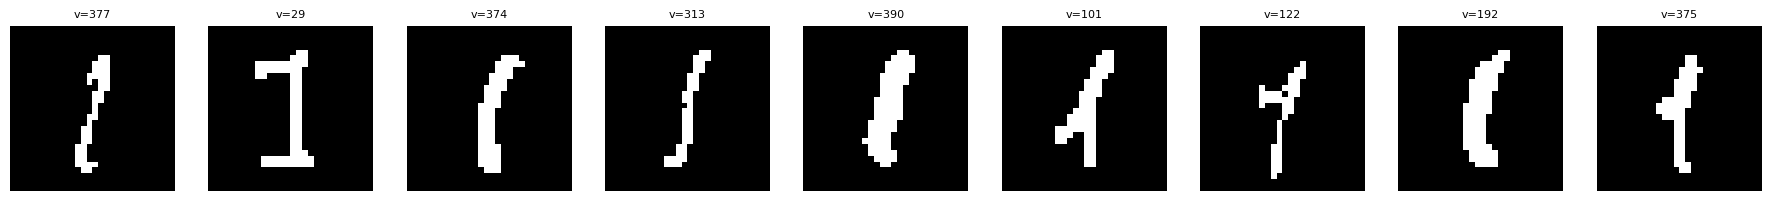

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# 1) Identify the maximum blur radius
r_max = max(patches_by_radius.keys())

# 2) Grab patch 0 at that level
patch0_edges = patches_by_radius[r_max][0]   # set of edge‐IDs in subg

# 3) Collect all unique vertices touched by those edges
vertices = set()
for eid in patch0_edges:
    u, v = subg.es[eid].tuple
    vertices.update([u, v])

# 4) Sample up to 9 of those vertices to display
sample_vs = random.sample(list(vertices), min(9, len(vertices)))

# 5) Plot their MNIST images
fig, axes = plt.subplots(1, len(sample_vs), figsize=(len(sample_vs)*2, 2))
for ax, v in zip(axes, sample_vs):
    orig_idx = subg.vs[v]['orig_idx']
    img      = vectors_np[orig_idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"v={v}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()


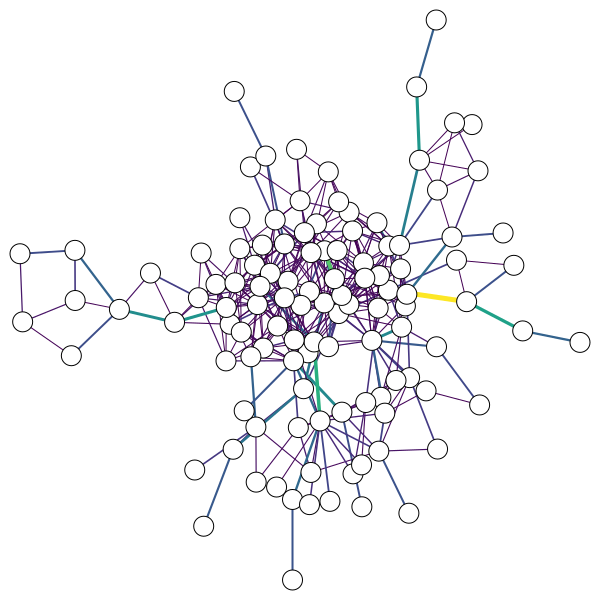

In [ ]:
verts = set()
for eid in patch0_edges:
    u,v = subg.es[eid].tuple
    verts |= {u,v}
G = subg.subgraph(sorted(verts))

lay = G.layout("kk", weights=G.es["weight"])

loads = np.array(G.es['load'])
norm = plt.Normalize(vmin=loads.min(), vmax=loads.max())
edge_colors = [plt.cm.viridis(norm(l)) for l in loads]
edge_widths = 1 + 4*(loads - loads.min())/(loads.max()-loads.min())


ig.plot(G,
        layout=lay,
        edge_color=edge_colors,
        edge_width=edge_widths,
        vertex_size=20,
        vertex_color="white")


In [ ]:
# First install the GraphRicciCurvature package if not already installed:
# !pip install GraphRicciCurvature

import networkx as nx
from GraphRicciCurvature.OllivierRicci import OllivierRicci

# 1) Convert igraph subg into a NetworkX graph
G_nx = nx.Graph()
for v in subg.vs:
    G_nx.add_node(v.index)
for e in subg.es:
    u, v = e.tuple
    # use the same weight you had on the igraph edges
    w = e['weight']
    G_nx.add_edge(u, v, weight=w)

# 2) Compute Ollivier-Ricci curvature
#    alpha=0.5 is the usual choice for the lazy random walk
orc = OllivierRicci(G_nx, alpha=0.5, verbose="ERROR")
orc.compute_ricci_curvature()

# 1) Grab the updated NetworkX graph
G_rc = orc.G

# 2) Extract the curvature in the same order as subg.es
ricci_vals = []
for u, v, data in G_rc.edges(data=True):
    # data is the dict of edge attributes
    val = data.get('ricciCurvature')
    if val is None:
        raise KeyError(f"Edge {(u,v)} has no 'ricciCurvature'")
    ricci_vals.append(val)

# 3) Attach back to your igraph subg (assuming edges were added in the same order)
subg.es['ricci'] = ricci_vals

# 4) Quick sanity check
for eid in range(min(50, subg.ecount())):
    u, v = subg.es[eid].tuple
    print(f"edge {eid} ({u}-{v}): ricci = {subg.es[eid]['ricci']:.4f}")


edge 0 (0-122): ricci = -0.0617
edge 1 (0-131): ricci = -0.1106
edge 2 (0-155): ricci = -0.0897
edge 3 (0-161): ricci = 0.1391
edge 4 (0-170): ricci = -0.2569
edge 5 (0-225): ricci = -0.0698
edge 6 (0-227): ricci = -0.0670
edge 7 (0-234): ricci = 0.0517
edge 8 (0-235): ricci = 0.0534
edge 9 (0-245): ricci = -0.1084
edge 10 (0-256): ricci = 0.0561
edge 11 (0-289): ricci = -0.1750
edge 12 (0-292): ricci = 0.0508
edge 13 (0-308): ricci = 0.0068
edge 14 (0-310): ricci = -0.2625
edge 15 (0-328): ricci = -0.0975
edge 16 (0-331): ricci = 0.0222
edge 17 (0-347): ricci = 0.0594
edge 18 (0-362): ricci = 0.0999
edge 19 (0-388): ricci = 0.0752
edge 20 (0-393): ricci = 0.0850
edge 21 (0-400): ricci = 0.0040
edge 22 (0-411): ricci = 0.0230
edge 23 (0-427): ricci = -0.1388
edge 24 (0-430): ricci = 0.0777
edge 25 (0-431): ricci = 0.0792
edge 26 (0-450): ricci = 0.2609
edge 27 (1-184): ricci = 0.0767
edge 28 (2-174): ricci = 0.1351
edge 29 (2-356): ricci = -0.0163
edge 30 (3-283): ricci = 0.1148
edge 3

My summarized understanding of Oliver-Ricci curvature

ChatGPT said:
Your core insight (in your own words):

“We give each endpoint u of an edge (u,v) a little probability pile mₙ — half the mass sits at u, the other half is spread equally among its neighbors. We do the same for v. To compare those two piles, we compute the minimal “work” (mass × distance) needed to reshape the distribution of mᵤ into mᵥ. So if node u has neighbors a,b and v has d,e - we want to move weight from u,a,b to v,d,e for example. That is the Earth-Mover’s distance W₁. We then divide W₁ by the edge’s own weight (the Euclidean distance between u and v) to normalize because the edge weight is 1 (the total weight/probability to a node * edge weight)

Oliver Ricci = 1 - ((work done meaning mass * distance moved) / (edge weight))

This specifically measures "curvature/connectedness" of an edge NOT node.

If many neighbors overlap, almost no mass moves (W₁≈0), so κ=1.

If they share no neighbors, you must haul the full unit of mass across that edge (W₁=d), so κ=0.

If the imbalance is extreme and some mass must detour farther than one hop, W₁>d and thus κ<0.”

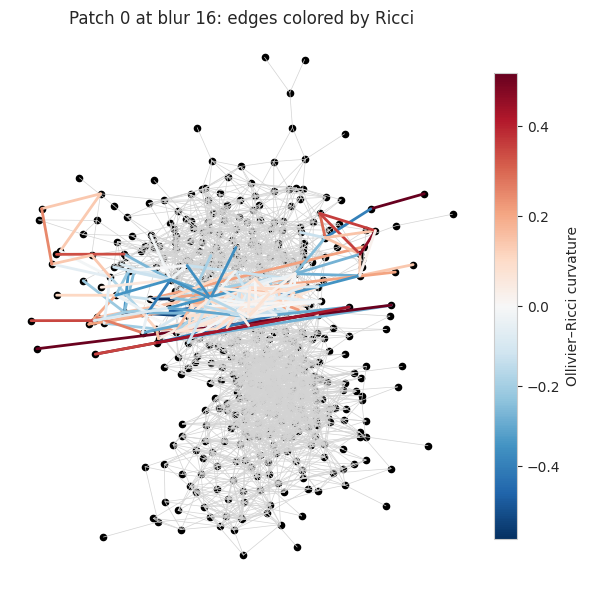

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- Assumes subg, patches_by_radius, and ricci curvature on subg.es['ricci'] defined ---

# 1) Choose the patch to visualize (max blur, patch 0 here)
r_max = max(patches_by_radius.keys())
patch_edges = set(patches_by_radius[r_max][0])

# 2) Compute a 2D layout for the subgraph
layout = subg.layout("kk", weights=subg.es['weight'])
coords = np.array(layout.coords)

# 3) Extract curvature values
ricci_vals = np.array(subg.es['ricci'])
vmin, vmax = ricci_vals.min(), ricci_vals.max()
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
cmap = plt.cm.RdBu_r

# 4) Plot
fig, ax = plt.subplots(figsize=(6,6))
# draw all edges lightly
for eid, (u,v) in enumerate(subg.get_edgelist()):
    x0, y0 = coords[u]
    x1, y1 = coords[v]
    ax.plot([x0, x1], [y0, y1], color='lightgray', linewidth=0.5)

# draw patch edges colored by ricci
for eid in patch_edges:
    u, v = subg.es[eid].tuple
    x0, y0 = coords[u]; x1, y1 = coords[v]
    c = cmap(norm(subg.es[eid]['ricci']))
    ax.plot([x0, x1], [y0, y1], color=c, linewidth=2)

# draw nodes
ax.scatter(coords[:,0], coords[:,1], s=20, color='black')

# colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(ricci_vals)
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Ollivier–Ricci curvature")

ax.set_title(f"Patch 0 at blur {r_max}: edges colored by Ricci")
ax.axis('off')
plt.tight_layout()
plt.show()


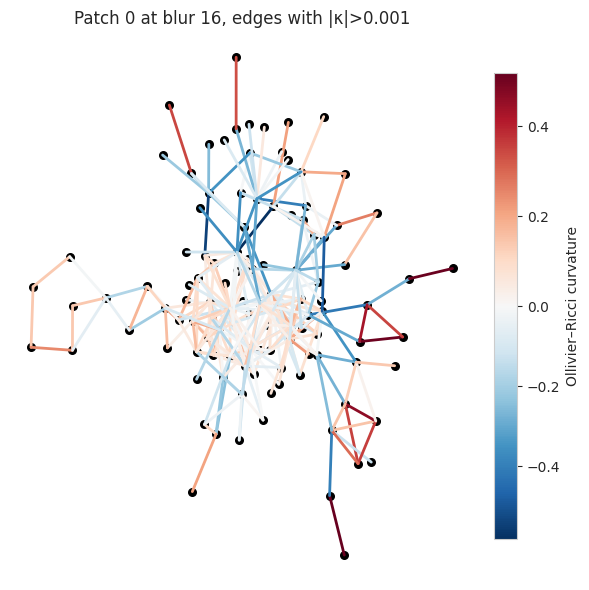

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- Assumes subg, patches_by_radius, and subg.es['ricci'] are defined ---

# 1) Select patch 0 at max blur
r_max = max(patches_by_radius.keys())
patch_edges = patches_by_radius[r_max][0]

# 2) Filter for edges with meaningful curvature
ricci_vals_full = np.array(subg.es['ricci'])
threshold = 1e-3
edges_to_draw = [eid for eid in patch_edges if abs(ricci_vals_full[eid]) > threshold]

# 3) Collect only the nodes incident on those edges
nodes = set()
for eid in edges_to_draw:
    u, v = subg.es[eid].tuple
    nodes.update([u, v])
nodes = list(nodes)

# 4) Induced subgraph for layout
induced = subg.induced_subgraph(nodes)
layout = induced.layout("kk", weights=induced.es['weight'])
coords = np.array(layout.coords)

# Map original→layout coords
orig_to_coord = {orig: tuple(coords[i]) for i, orig in enumerate(nodes)}

# 5) Prepare colormap
vmin, vmax = ricci_vals_full.min(), ricci_vals_full.max()
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
cmap = plt.cm.RdBu_r

# 6) Plot only selected edges & nodes
fig, ax = plt.subplots(figsize=(6,6))
for eid in edges_to_draw:
    u, v = subg.es[eid].tuple
    x0, y0 = orig_to_coord[u]
    x1, y1 = orig_to_coord[v]
    c = cmap(norm(ricci_vals_full[eid]))
    ax.plot([x0, x1], [y0, y1], color=c, linewidth=2)

# Draw only the nodes in this patch
xs, ys = zip(*(orig_to_coord[v] for v in nodes))
ax.scatter(xs, ys, s=30, color='black')

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(ricci_vals_full)
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Ollivier–Ricci curvature")

ax.set_title(f"Patch 0 at blur {r_max}, edges with |κ|>{threshold}")
ax.axis('off')
plt.tight_layout()
plt.show()


In [102]:
# 1) Invert the “load” weights into positive costs
loads = subg.es['load']           # detour‐load per edge
M     = max(loads)
inv_w = [(M + 1) - w for w in loads]
subg.es['inv_weight'] = inv_w

# 2) Pick two example nodes
import random
u, v = random.sample(subg.vs.indices, 2)

# 3) Compute three shortest paths:
#    a) minimize detour‐load ("load")
#    b) maximize detour via inverted weights ("inv_weight")
#    c) minimize Euclidean distance ("weight")
paths = {}
for key in ('load', 'inv_weight', 'weight'):
    paths[key] = subg.get_shortest_paths(u, to=v, weights=key, mode='ALL')[0]

# 4) Helper to sum an edge attribute along a path
def path_sum(path, attr):
    return sum(
        subg.es[subg.get_eid(path[i], path[i+1])][attr]
        for i in range(len(path) - 1)
    )

# 5) Print results
# print(f"From node {u} to {v}:\n")
# print("Metric        Path                             Total")
# print("------------------------------------------------------------")
# print(f"Min-detour    {paths['load']}   {path_sum(paths['load'], 'load'):.2f}")
# print(f"Max-detour    {paths['inv_weight']}   {path_sum(paths['inv_weight'], 'load'):.2f}")
# print(f"Min‑Euclid    {paths['weight']}   {path_sum(paths['weight'], 'weight'):.2f}")
import pandas as pd
# 4) Build a table of metrics
rows = []
for metric, path in paths.items():
    detour = path_sum(path, 'load')
    euclid = path_sum(path, 'weight')
    rows.append({
        'Metric':         metric,
        'Path':           path,
        'Detour Load':    f"{detour:.2f}",
        'Euclidean Dist': f"{euclid:.2f}"
    })

df = pd.DataFrame(rows)

# 5) Print a nicely aligned table
print(df.to_string(index=False))

    Metric                                                                                              Path Detour Load Euclidean Dist
      load [248, 21, 190, 245, 430, 309, 329, 376, 16, 296, 57, 354, 435, 209, 178, 301, 243, 157, 187, 380]      605.87         111.27
inv_weight                                                           [248, 190, 252, 235, 90, 435, 208, 380]   312494.40          40.10
    weight                                                               [248, 289, 431, 238, 163, 379, 380]    82574.37          33.00
